# ShortGPT: Layer Pruning via Block Influence
**CAP6614 - Efficient AI | Team 7**

This notebook implements the full ShortGPT pipeline:
1. Load Llama-2-7B in 4-bit quantization
2. Load WikiText-2 calibration data
3. Compute Block Influence (BI) scores for every layer
4. Visualize layer redundancy
5. Prune least-important layers
6. Evaluate: perplexity + generation quality

**Paper:** Men et al., *"ShortGPT: Layers in Large Language Models are More Redundant Than You Expect"* (arXiv 2403.03853)

## 0. Setup

Run this cell first on Colab. If running locally, `pip install -r requirements.txt` instead.

In [1]:
# Colab only - skip if running locally with requirements.txt installed
!pip install -q -U bitsandbytes transformers accelerate datasets sentencepiece protobuf matplotlib tqdm

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import random

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

KeyboardInterrupt: 

---
## 1. Load Model in 4-bit Quantization

We use `bitsandbytes` NF4 quantization to fit Llama-2-7B into ~5 GB VRAM.

**Note:** `meta-llama/Llama-2-7b-hf` requires:
1. A HuggingFace account
2. Accepting Meta's license at https://huggingface.co/meta-llama/Llama-2-7b-hf
3. A HF token (set via `huggingface-cli login` or the cell below)

In [ ]:
# Authenticate with HuggingFace (run once)
# Colab - will prompt for token
from huggingface_hub import login
login()


In [ ]:
MODEL_ID = "meta-llama/Llama-2-7b-hf"

# 4-bit NF4 quantization config
# double_quant squeezes out a bit more memory savings on top of NF4
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print(f"Loading tokenizer from {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token  # Llama doesn't set a pad token by default

print(f"Loading model in 4-bit NF4...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",          # let accelerate handle device placement
    torch_dtype=torch.bfloat16,
)
model.eval()  # inference only, no training

NUM_LAYERS = len(model.model.layers)
HIDDEN_DIM = model.config.hidden_size
print(f"\nModel loaded successfully!")
print(f"  Layers:     {NUM_LAYERS}")
print(f"  Hidden dim: {HIDDEN_DIM}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

Loading tokenizer from TinyLlama/TinyLlama-1.1B-Chat-v1.0...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading model in 4-bit NF4...


Loading weights: 100%|██████████| 201/201 [00:32<00:00,  6.20it/s]



Model loaded successfully!
  Layers:     22
  Hidden dim: 2048
  Parameters: 0.62B


In [ ]:
import quick_benchmark
orig_benchmark = quick_benchmark.quick_benchmark(model, tokenizer, "Original Llama-2-7B")



Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Quick Benchmark: Original Llama-2-7B
Layers: 22
Parameters: 0.62B

 Benchmarking: 50 token generation 


Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Run 1: 0.45 tokens/sec (2198.56 ms/token)


Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Run 2: 1.05 tokens/sec (948.58 ms/token)
CUDA not available, skipping VRAM measurement

 Benchmarking: 100 token generation 


Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Run 1: 0.63 tokens/sec (1579.64 ms/token)
  Run 2: 0.63 tokens/sec (1579.46 ms/token)
CUDA not available, skipping VRAM measurement
Summary
Model: 22 layers, 0.62B params
Speed (50 tokens): 0.8 tokens/sec
Speed (100 tokens): 0.6 tokens/sec
Peak VRAM (100 tokens): N/A (CPU mode)


---
## 2. Load Calibration Data (WikiText-2)

We sample random subsequences from the WikiText-2 training set.
This is the standard calibration approach used by SparseGPT, WANDA, and ShortGPT.

In [ ]:
SEQLEN = 512       # tokens per sample (512 works on T4; paper uses 2048)
NSAMPLES = 128     # number of calibration samples (standard for SparseGPT/WANDA)


def get_wikitext2_calibration(nsamples, seqlen, tokenizer, seed=42):
    """Load WikiText-2 and return calibration samples + test encoding."""
    traindata = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
    testdata = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")

    # Concat all training text into one long string, then tokenize it all at once
    trainenc = tokenizer(
        " ".join(traindata["text"]),
        return_tensors="pt",
    )
    testenc = tokenizer(
        "\n\n".join(testdata["text"]),
        return_tensors="pt",
    )

    # Grab random windows from the tokenized training data
    random.seed(seed)
    samples = []
    for _ in range(nsamples):
        i = random.randint(0, trainenc.input_ids.shape[1] - seqlen - 1)
        samples.append(trainenc.input_ids[:, i : i + seqlen])  # shape: (1, seqlen)

    return samples, testenc


print("Loading WikiText-2...")
calibration_data, test_encoding = get_wikitext2_calibration(
    NSAMPLES, SEQLEN, tokenizer, seed=SEED
)
print(f"Calibration: {len(calibration_data)} samples x {SEQLEN} tokens")
print(f"Test set: {test_encoding.input_ids.shape[1]} tokens")

Loading WikiText-2...


C:\Users\nicol\PycharmProjects\Captest\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\nicol\.cache\huggingface\hub\datasets--wikitext. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating validation split: 100%|██████████| 3760/3760 [00:00<00:00, 251660.92 examples/s]
Token indices sequence

Calibration: 128 samples x 512 tokens
Test set: 341469 tokens


---
## 3. Block Influence (BI) Metric

For each layer *i*, Block Influence measures how much the layer changes
the hidden state passing through it:

$$\text{BI}_i = 1 - \mathbb{E}_{X,t}\left[\frac{X_{i,t}^\top \cdot X_{i+1,t}}{\|X_{i,t}\| \cdot \|X_{i+1,t}\|}\right]$$

- **BI close to 0** = layer barely changes anything (redundant, safe to remove)
- **BI close to 1** = layer makes big changes to the hidden state (important, keep it)

In [ ]:
def block_influence(x_in, x_out):
    """Compute per-token Block Influence between layer input and output.
    BI = 1 - cosine_sim(input, output). Returns (B*S,) tensor of scores in [0,1].
    """
    B, S, D = x_in.shape

    # Flatten batch + sequence dims so we get one cosine sim value per token
    flat_in = x_in.reshape(-1, D).float()
    flat_out = x_out.reshape(-1, D).float()

    sim = F.cosine_similarity(flat_in, flat_out, dim=-1)  # shape: (B*S,)
    sim = sim.nan_to_num(nan=0.5)  # safety net for zero-norm edge cases
    return 1.0 - sim

---
## 4. Compute BI Scores Across All Layers

We forward-pass all calibration samples through the model with `output_hidden_states=True`.
This gives us the hidden state at every layer boundary without needing manual hooks.

`hidden_states[i]` = input to layer `i`, `hidden_states[i+1]` = output of layer `i`.

In [ ]:
def compute_bi_scores(model, calibration_data, num_layers):
    """Compute average BI score for every layer across all calibration samples."""
    bi_scores = [0.0] * num_layers
    total_tokens = 0

    with torch.no_grad():
        for inp in tqdm(calibration_data, desc="Computing BI scores"):
            outputs = model(
                input_ids=inp.to(DEVICE),
                output_hidden_states=True,  # this gives us hidden states at every layer
                use_cache=False,
                return_dict=True,
            )
            # hidden_states is a tuple of (num_layers + 1) tensors
            # hidden_states[i] = input to layer i
            # hidden_states[i+1] = output of layer i
            hidden_states = outputs.hidden_states
            n_tokens = inp.shape[1]
            total_tokens += n_tokens

            for i in range(num_layers):
                bi = block_influence(hidden_states[i], hidden_states[i + 1])
                bi_scores[i] += bi.sum().item()

    # Average over all tokens across all samples
    bi_scores = [s / total_tokens for s in bi_scores]
    return bi_scores


print(f"Running {NSAMPLES} calibration samples through {NUM_LAYERS} layers...")
bi_scores = compute_bi_scores(model, calibration_data, NUM_LAYERS)

print("\nBlock Influence scores per layer:")
for i, score in enumerate(bi_scores):
    bar = "█" * int(score * 100)
    print(f"  Layer {i:2d}: {score:.4f}  {bar}")

Running 128 calibration samples through 22 layers...


Computing BI scores: 100%|██████████| 128/128 [51:06<00:00, 23.96s/it]


Block Influence scores per layer:
  Layer  0: 0.2555  █████████████████████████
  Layer  1: 0.1248  ████████████
  Layer  2: 0.1436  ██████████████
  Layer  3: 0.1358  █████████████
  Layer  4: 0.1296  ████████████
  Layer  5: 0.1296  ████████████
  Layer  6: 0.1432  ██████████████
  Layer  7: 0.1606  ████████████████
  Layer  8: 0.1482  ██████████████
  Layer  9: 0.1343  █████████████
  Layer 10: 0.1151  ███████████
  Layer 11: 0.1211  ████████████
  Layer 12: 0.1247  ████████████
  Layer 13: 0.1276  ████████████
  Layer 14: 0.1288  ████████████
  Layer 15: 0.1368  █████████████
  Layer 16: 0.1350  █████████████
  Layer 17: 0.0985  █████████
  Layer 18: 0.1127  ███████████
  Layer 19: 0.1016  ██████████
  Layer 20: 0.1290  ████████████
  Layer 21: 0.2612  ██████████████████████████


---
## 5. Visualize Layer Importance

This reproduces **Figure 3** from the ShortGPT paper, the layer importance plot.
Expect to see: first few layers and the last layer have high BI; middle-to-later layers are redundant.

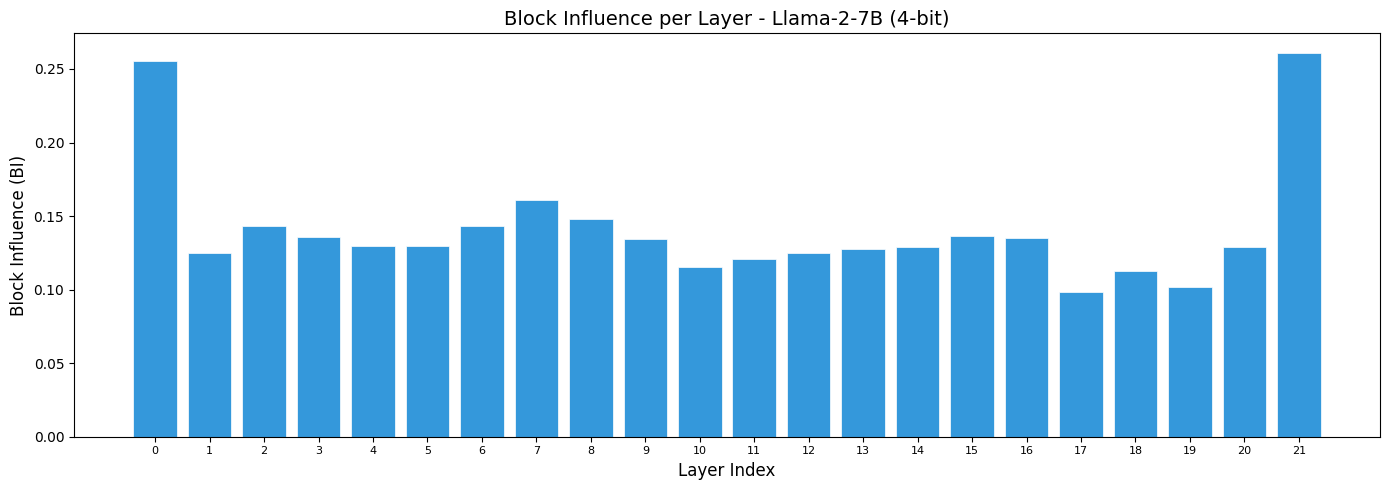

Saved: bi_scores.png

Most redundant layers (lowest BI):  [17, 19, 18, 10, 11]
Most critical layers (highest BI):   [2, 8, 7, 0, 21]


In [ ]:
def plot_bi_scores(bi_scores, model_name="Llama-2-7B (4-bit)", n_prune=None):
    """Bar chart of BI scores per layer, with optional pruning threshold."""
    fig, ax = plt.subplots(figsize=(14, 5))

    layers = list(range(len(bi_scores)))

    # Color bars: red = will be pruned, blue = kept
    if n_prune is not None:
        prune_set = set(np.argsort(bi_scores)[:n_prune])
        colors = ["#e74c3c" if i in prune_set else "#3498db" for i in layers]
    else:
        colors = "#3498db"

    ax.bar(layers, bi_scores, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Layer Index", fontsize=12)
    ax.set_ylabel("Block Influence (BI)", fontsize=12)
    ax.set_title(f"Block Influence per Layer - {model_name}", fontsize=14)
    ax.set_xticks(layers)
    ax.set_xticklabels(layers, fontsize=8)

    if n_prune is not None:
        # Add threshold line
        threshold = sorted(bi_scores)[n_prune]
        ax.axhline(y=threshold, color="#e74c3c", linestyle="--", alpha=0.7,
                   label=f"Pruning threshold (remove {n_prune} layers)")
        ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig("bi_scores.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: bi_scores.png")


# Plot without pruning threshold first
plot_bi_scores(bi_scores)

# Identify most and least important layers
ranked = np.argsort(bi_scores)
print(f"\nMost redundant layers (lowest BI):  {ranked[:5].tolist()}")
print(f"Most critical layers (highest BI):   {ranked[-5:].tolist()}")

---
## 5.5 Baseline Perplexity (Before Pruning)

We need the unpruned model's perplexity so we have something to compare against after pruning.
**Run this before the pruning step.**

In [ ]:
def evaluate_perplexity(model, test_encoding, seqlen=512):
    """
    Calculate perplexity on a test set using non-overlapping windows.
    Lower perplexity = better predictions.
    """
    test_ids = test_encoding.input_ids
    n_tokens = test_ids.shape[1]
    nlls = []

    with torch.no_grad():
        for i in tqdm(range(0, n_tokens - seqlen, seqlen), desc="Evaluating PPL"):
            batch = test_ids[:, i : i + seqlen].to(DEVICE)
            outputs = model(
                input_ids=batch,
                use_cache=False,
                return_dict=True,
            )
            # Shift logits: predict token i+1 from position i
            # Cast to float32 before CE to avoid precision blow-up in fp16/bf16
            logits = outputs.logits[:, :-1, :].float().contiguous()
            labels = batch[:, 1:].contiguous()
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                labels.view(-1),
                reduction="mean",
            )
            nlls.append(loss.item())

    avg_nll = np.mean(nlls)
    ppl = np.exp(avg_nll)
    return ppl


# Get the baseline BEFORE we prune anything
print("Evaluating BASELINE (unpruned) perplexity on WikiText-2 test set...")
baseline_ppl = evaluate_perplexity(model, test_encoding, seqlen=SEQLEN)
print(f"\nBaseline PPL (unpruned): {baseline_ppl:.2f}")
print("(For reference: original Llama-2-7B PPL on WikiText-2 is around 5.5)")

Evaluating BASELINE (unpruned) perplexity on WikiText-2 test set...


Evaluating PPL:   3%|▎         | 20/666 [08:33<4:36:19, 25.66s/it]


KeyboardInterrupt: 

---
## 6. Layer Removal

Remove the least important layers from `model.model.layers`. A few things to watch out for:
- Delete layers in **reverse index order** so the indices don't shift as you go
- **Re-index** `self_attn.layer_idx` on the remaining layers, otherwise the KV cache breaks
- **Update** `model.config.num_hidden_layers` so saving/loading the model still works

In [ ]:
def remove_layers(model, bi_scores, n_prune):
    """Remove the n_prune layers with the lowest BI scores (most redundant).
    Returns a sorted list of removed layer indices.
    """
    # Sort layers by BI and pick the n_prune lowest ones
    layers_to_remove = np.argsort(bi_scores)[:n_prune].tolist()
    print(f"Removing {n_prune} layers: {sorted(layers_to_remove)}")

    # IMPORTANT: delete from highest index to lowest, otherwise the
    # indices shift as we delete and we'd remove the wrong layers
    for idx in sorted(layers_to_remove, reverse=True):
        del model.model.layers[idx]

    # Fix the layer_idx on each remaining layer's attention module.
    # If we skip this step, the KV cache will try to access wrong positions
    # and the model will crash or give garbage output.
    for new_idx, layer in enumerate(model.model.layers):
        layer.self_attn.layer_idx = new_idx

    # Keep the config in sync so save/load works correctly
    model.config.num_hidden_layers = len(model.model.layers)

    return sorted(layers_to_remove)

In [ ]:
# How many layers to prune?
# Paper removes ~25% as a good baseline. For 32-layer Llama-2-7B, that's 8 layers.
N_PRUNE = 8  # ~25% of 32 layers

# Show the plot with pruning threshold highlighted
plot_bi_scores(bi_scores, n_prune=N_PRUNE)

print(f"\nOriginal layers: {NUM_LAYERS}")
print(f"Layers to remove: {N_PRUNE} ({N_PRUNE/NUM_LAYERS*100:.0f}%)")
print(f"Remaining layers: {NUM_LAYERS - N_PRUNE}")

In [ ]:
# Actually remove the layers
removed = remove_layers(model, bi_scores, N_PRUNE)

print(f"\nPruned model now has {len(model.model.layers)} layers.")
print(f"Remaining params: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

In [ ]:
pruned_benchmark = quick_benchmark.quick_benchmark(model, tokenizer, "Pruned Llama-2-7B")

print("Performance Comparison")
print(f"Layers: 32 → {len(model.model.layers)}")
print(f"Speed (100 tokens): {orig_benchmark['speed_100']['tokens_per_sec_mean']:.1f} → {pruned_benchmark['speed_100']['tokens_per_sec_mean']:.1f} tokens/sec")
print(f"VRAM peak (100 tokens): {orig_benchmark['vram_100']['vram_peak_gb']:.2f} → {pruned_benchmark['vram_100']['vram_peak_gb']:.2f} GB")

---
## 7. Evaluate Pruned Model Perplexity

Now we run the same perplexity evaluation on the pruned model.
Compare this against the baseline we computed in section 5.5.

In [ ]:
# Reuse the same evaluate_perplexity function from section 5.5
print("Evaluating PRUNED model perplexity on WikiText-2 test set...")
pruned_ppl = evaluate_perplexity(model, test_encoding, seqlen=SEQLEN)

print(f"\nBaseline PPL (unpruned): {baseline_ppl:.2f}")
print(f"Pruned PPL ({N_PRUNE} layers removed): {pruned_ppl:.2f}")
print(f"PPL increase: {pruned_ppl - baseline_ppl:.2f} ({((pruned_ppl - baseline_ppl) / baseline_ppl) * 100:.1f}%)")

---
## 8. Evaluate: Generation Quality (Sanity Check)

Quick qualitative test - does the pruned model still produce coherent text?

In [ ]:
def generate_text(model, tokenizer, prompt, max_new_tokens=100):
    """Quick helper to generate text from a prompt."""
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
        )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)


# A few test prompts to see if the pruned model still makes sense
test_prompts = [
    "The theory of relativity states that",
    "In a large neural network, the deeper layers",
    "The capital of France is",
]

print("=" * 70)
print("PRUNED MODEL GENERATION SAMPLES")
print("=" * 70)
for prompt in test_prompts:
    output = generate_text(model, tokenizer, prompt)
    print(f"\nPrompt: {prompt}")
    print(f"Output: {output}")
    print("-" * 70)

---
## 9. Save Pruned Model (Optional)

Save the pruned model so the team can load it directly without re-running pruning.

In [ ]:
# Uncomment to save
# SAVE_DIR = "llama2-7b-shortgpt-pruned"
# model.save_pretrained(SAVE_DIR)
# tokenizer.save_pretrained(SAVE_DIR)
# print(f"Saved pruned model to {SAVE_DIR}/")

---
## 10. Summary Table

Print a clean results summary for the report.

In [ ]:
print("\n" + "=" * 50)
print("RESULTS SUMMARY")
print("=" * 50)
print(f"Model:              {MODEL_ID}")
print(f"Quantization:       4-bit NF4 (double quant)")
print(f"Original layers:    {NUM_LAYERS}")
print(f"Pruned layers:      {N_PRUNE} ({N_PRUNE/NUM_LAYERS*100:.0f}%)")
print(f"Remaining layers:   {NUM_LAYERS - N_PRUNE}")
print(f"Layers removed:     {removed}")
print(f"Calibration:        WikiText-2, {NSAMPLES} samples x {SEQLEN} tokens")
print(f"Baseline PPL:       {baseline_ppl:.2f}")
print(f"Pruned model PPL:   {pruned_ppl:.2f}")
print(f"PPL increase:       {pruned_ppl - baseline_ppl:.2f} ({((pruned_ppl - baseline_ppl) / baseline_ppl) * 100:.1f}%)")
print("=" * 50)